Autor: Oscar Albarracin

Proyecto personal de Marchine Learning


MAE: 0.71
R2: 0.99


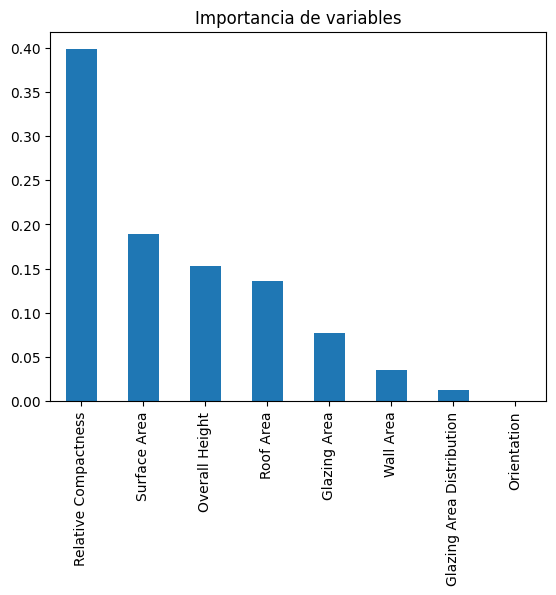

In [1]:
#  Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

#  Cargar dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00242/ENB2012_data.xlsx"
df = pd.read_excel(url)

#  Renombrar columnas
df.columns = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution",
    "Heating Load", "Cooling Load"
]

#  Selección de variables
X = df.drop(["Heating Load", "Cooling Load"], axis=1)
y = df["Heating Load"]

#  División
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Modelo más potente
model = RandomForestRegressor(n_estimators=100, max_depth=5,random_state=42)
model.fit(X_train, y_train)

#  Predicción
y_pred = model.predict(X_test)

#  Métricas
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")

# 📊 IMPORTANCIA DE VARIABLES (esto es clave )
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

# 📊 Visualización
plt.figure()
importances.plot(kind='bar')
plt.title("Importancia de variables")
plt.show()

In [2]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R2 CV:", scores.mean())

R2 CV: 0.9507742468375664


In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 10]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='r2')

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)

Best params: {'max_depth': 10, 'n_estimators': 100}


In [4]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred_best))

print("R2:", r2_score(y_test, y_pred_best))

MAE: 0.35629201902174246
R2: 0.99766153319003


In [5]:
print("Modelo base R2:", r2)
print("Modelo optimizado R2:", r2_score(y_test, y_pred_best))

Modelo base R2: 0.9894452251810757
Modelo optimizado R2: 0.99766153319003


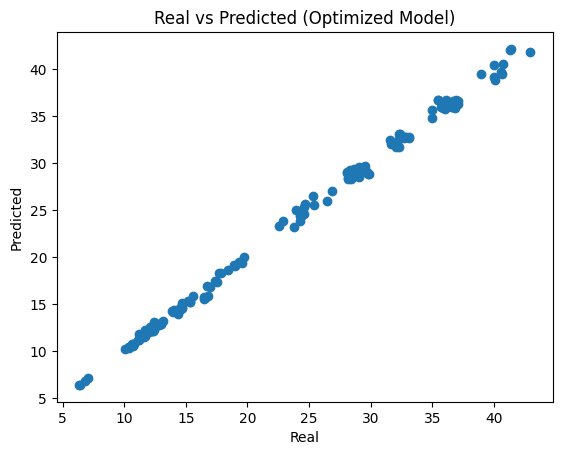

In [6]:
plt.figure()
plt.scatter(y_test, y_pred_best)
plt.xlabel("Real")
plt.ylabel("Predicted")
plt.title("Real vs Predicted (Optimized Model)")
plt.show()